# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
ds_train = load_dataset('cifar10', split='train')
ds_test = load_dataset('cifar10', split='test')

x_train = np.stack([np.array(ds_train[i]['img'], dtype=np.uint8) for i in range(len(ds_train))])
y_train = np.array([[ds_train[i]['label']] for i in range(len(ds_train))])
x_test = np.stack([np.array(ds_test[i]['img'], dtype=np.uint8) for i in range(len(ds_test))])
y_test = np.array([[ds_test[i]['label']] for i in range(len(ds_test))])

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

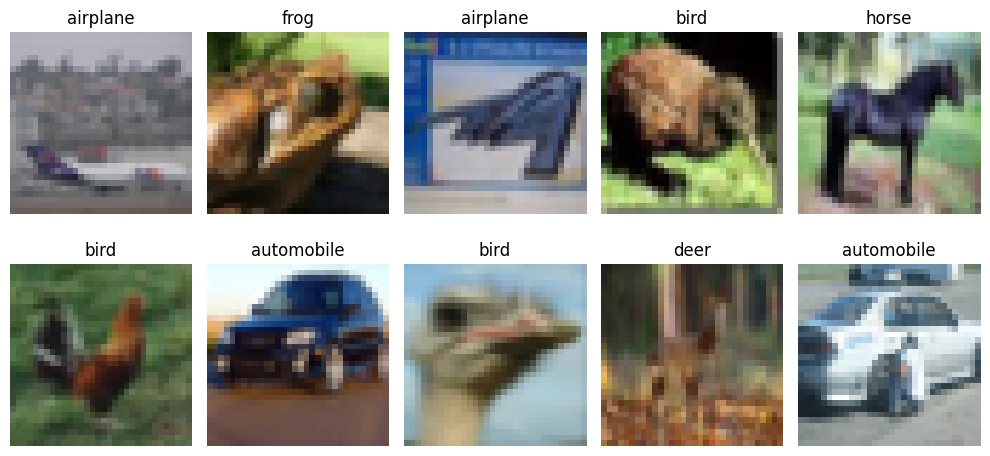

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/Users/aryanjha/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


  1/704 ━━━━━━━━━━━━━━━━━━━━ 7:44 660ms/step - accuracy: 0.1562 - loss: 2.3222

  7/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1006 - loss: 3.2070    

 14/704 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1068 - loss: 3.1915

...

680/704 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3896 - loss: 1.6900

687/704 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3896 - loss: 1.6900

693/704 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3896 - loss: 1.6900

699/704 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3896 - loss: 1.6900

704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3896 - loss: 1.6900 - val_accuracy: 0.4294 - val_loss: 1.6452


In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4062 - loss: 1.5562

 36/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4277 - loss: 1.6533

 71/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4369 - loss: 1.6422

103/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4382 - loss: 1.6407

137/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4387 - loss: 1.6396

...

242/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4393 - loss: 1.6373

275/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4392 - loss: 1.6373

311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4389 - loss: 1.6375

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4389 - loss: 1.6375


ANN Test Accuracy: 0.43540000915527344


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/Users/aryanjha/miniconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


  1/704 ━━━━━━━━━━━━━━━━━━━━ 9:07 779ms/step - accuracy: 0.0781 - loss: 3.1830

  3/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.1024 - loss: 3.1405  

  5/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.1135 - loss: 3.0364

...

697/704 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8507 - loss: 0.4189

699/704 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8507 - loss: 0.4189

701/704 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8507 - loss: 0.4190

703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8506 - loss: 0.4190

704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.8506 - loss: 0.4191 - val_accuracy: 0.7244 - val_loss: 0.9289


In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8125 - loss: 0.4610

 11/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7331 - loss: 0.9423 

 22/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7264 - loss: 0.9460

 32/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7236 - loss: 0.9532

 44/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7235 - loss: 0.9542

...

286/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7231 - loss: 0.9655

297/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7230 - loss: 0.9658

307/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7228 - loss: 0.9660

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7227 - loss: 0.9662


CNN Test Accuracy: 0.7179999947547913


## 📈 Compare Learning Curves

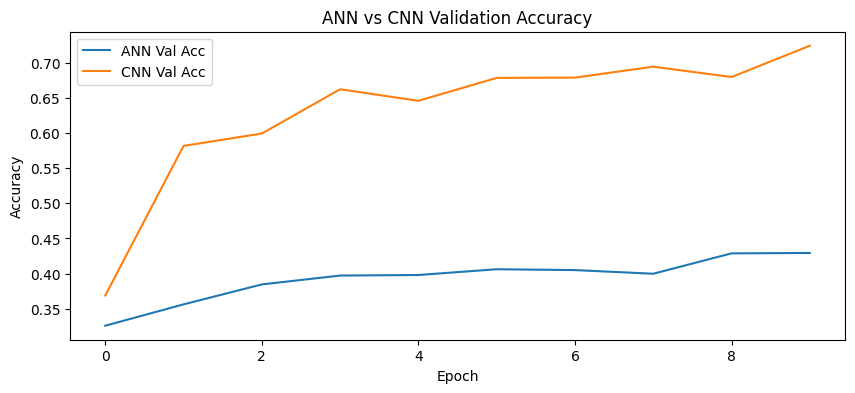

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4354
1,CNN,0.7180


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**